# Lab Work 2

## Импорт библиотек

In [1]:
!pip install gensim
!pip install fasttext

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 470.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 11.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.1
    Uninstalling scipy-1.14.1:
      Successfully uninstalled scipy-1.14.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 2.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-2.13.6-py3-none-any.whl.metadata (9.5 kB)
Using cached pybind11

In [1]:
import pandas as pd
import numpy as np
from gensim.models import FastText
from gensim.models import KeyedVectors
import nltk
import nltk.corpus
import nltk.tokenize
from nltk.corpus import stopwords
from string import punctuation
import re
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import fasttext
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from torch.utils.data import DataLoader, TensorDataset
from huggingface_hub import hf_hub_download
from collections import defaultdict
import datetime
import matplotlib.pyplot as plt
import seaborn as sns


## Data Loading

In [2]:
#nltk.download()
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
path_to_data = 'data/'
path_to_fasttext = 'fasttext/'
path_to_models = 'models/'
negative_file = path_to_data + 'negative.csv'
positive_file = path_to_data + 'positive.csv'
fasttext_model = path_to_fasttext + 'model.model'
fasttext_model = '/content/my_fast_text.csv'

In [7]:
negative_df = pd.read_csv(negative_file, delimiter=";",header=None, names=["id", "tdate", "tmane",'ttext', 'ttype', 'trep', 'trtv','tfav', 'tstcount', 'tfol', 'tfrien', 'listcount'])
positive_df = pd.read_csv(positive_file, delimiter=";",header=None, names=["id", "tdate", "tmane",'ttext', 'ttype', 'trep', 'trtv','tfav', 'tstcount', 'tfol', 'tfrien', 'listcount'])

## DELETE

In [8]:
negative_df = negative_df[:1000]
positive_df = positive_df[:1000]

In [9]:
sentiment = pd.concat([negative_df, positive_df])
sentiment=sentiment.loc[:,['ttext', 'ttype']]

In [10]:
sentiment.loc[(sentiment.ttype < 0), ('ttype')] = 0
sentiment

,ttext,ttype
0,на работе был полный пиддес :| и так каждое за...,0
1,"Коллеги сидят рубятся в Urban terror, а я из-з...",0
2,@elina_4post как говорят обещаного три года жд...,0
3,"Желаю хорошего полёта и удачной посадки,я буду...",0
4,"Обновил за каким-то лешим surf, теперь не рабо...",0
...,...,...
995,@Denis_Shvedak Рискни) В рамку не эту тогда) И...,1
996,@Lei_Ri Спасибо) считаю найти свое место очень...,1
997,уаааа)))))) сейчас около меня прошел паренек с...,1
998,За монгол коментийн 2 оо vзэж жаахан хэрэгт ду...,1


## Preprocessing

In [11]:
X=sentiment['ttext'].values.tolist()
y=sentiment['ttype'].values.tolist()

In [12]:
punctuations = list(punctuation)
punkt = ['``','...',"''",'«','»','…','”','”','“','-','–','..']
punctuations.extend(punkt)

stop_words = set(stopwords.words('russian'))
stop = []
for i in stop_words:
  if i not in ['нет','не','хорошо','иногда',
               'наконец','ни','никогда','ничего',
               'опять','разве','совсем','уже']:
      stop.append(i)

def tokenize(text):
    text = re.sub('[^ЙйёЁА-Яа-я0-9 ]', '', text)
    text = re.sub('\s+', ' ', text).strip()
    text_token = nltk.word_tokenize(text)
    text_word = [x.lower() for x in text_token if x not in punctuations]
    text_word = [i for i in text_word if i not in stop]
    return text_word


In [13]:
X_token = [tokenize(t) for t in X]

In [14]:
X_token[:10]

[['работе', 'полный', 'пиддес', 'каждое', 'закрытие', 'месяца', 'свихнусь'],
 ['коллеги', 'сидят', 'рубятся', 'изза', 'долбанной', 'винды', 'не', 'могу'],
 ['4', 'говорят', 'обещаного', 'года', 'ждут'],
 ['желаю',
  'хорошего',
  'полёта',
  'удачной',
  'посадкия',
  'буду',
  'очень',
  'сильно',
  'скучать',
  '3'],
 ['обновил', 'какимто', 'лешим', 'не', 'работает', 'простоплеер'],
 ['котёнка', 'вчера', 'носик', 'разбила', 'плакала', 'расстраивалась'],
 ['55',
  'зашли',
  'опять',
  'затихарился',
  'прямо',
  'физически',
  'страдаю',
  'долго',
  'молчит'],
 ['вообще', 'не', 'болею', 'не', 'выздоравливаю'],
 ['микрофраза', 'учимся', 'срать', 'кирпичами', 'режиме', 'нонстоп'],
 ['хочу', 'тобой', 'помириться', 'сука', 'гордая', 'никогда', 'не', 'сделаю']]

## Fasttext

In [15]:
# 1. Функция для создания архитектуры модели с гибкими параметрами
def create_model(input_dim, layers_config, output_dim):
    """
    Создает модель нейронной сети с заданной конфигурацией слоев

    Параметры:
    input_dim - размер входных признаков
    layers_config - конфигурация скрытых слоев, может быть:
                   - int (одинаковое кол-во нейронов во всех слоях)
                   - list (разное кол-во нейронов по слоям, например [128, 64, 32])
    output_dim - размер выходного слоя
    """
    class DynamicFeedForwardNN(nn.Module):
        def __init__(self, input_dim, layers_config, output_dim):
            super(DynamicFeedForwardNN, self).__init__()

            # Обработка конфигурации слоев
            if isinstance(layers_config, int):
                # Если передано одно число - создаем все слои с таким кол-вом нейронов
                hidden_dims = [layers_config] * len(layers_config)
            elif isinstance(layers_config, (list, tuple)):
                # Если передан список - используем как есть
                hidden_dims = layers_config
            else:
                raise ValueError("layers_config должен быть int или list")

            # Создаем слои динамически
            layers = []
            prev_dim = input_dim

            for i, dim in enumerate(hidden_dims):
                layers.append(nn.Linear(prev_dim, dim))
                layers.append(nn.ReLU())
                prev_dim = dim

            # Последний слой
            layers.append(nn.Linear(prev_dim, output_dim))
            layers.append(nn.Softmax(dim=1))

            self.layers = nn.Sequential(*layers)
            self.num_layers = len(hidden_dims)

        def forward(self, x):
            return self.layers(x)

    return DynamicFeedForwardNN(input_dim, layers_config, output_dim)

In [16]:
# 2. Функция для извлечения признаков из FastText
def extract_features(tokens):
    model_path = hf_hub_download(repo_id="facebook/fasttext-ru-vectors", filename="model.bin")
    fasttext_model = fasttext.load_model(model_path)

    features = []
    for token_list in tokens:
        vectors = [fasttext_model.get_word_vector(token) for token in token_list]
        if len(vectors) > 0:
            avg_vector = np.mean(vectors, axis=0)
        else:
            avg_vector = np.zeros(fasttext_model.get_dimension())
        features.append(avg_vector)
    return np.array(features)

In [17]:
# 3. Функция для подготовки данных
def prepare_data(X_features, y, test_size=0.2, batch_size=32):
    X_train, X_test, y_train, y_test = train_test_split(
        X_features, y, test_size=test_size, random_state=42
    )

    X_train_tensor = torch.FloatTensor(X_train)
    X_test_tensor = torch.FloatTensor(X_test)
    y_train_tensor = torch.LongTensor(y_train)
    y_test_tensor = torch.LongTensor(y_test)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    return train_loader, test_loader, len(X_train), len(X_test)

In [18]:
# 4. Функция для оценки модели
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            _, preds = torch.max(outputs.data, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * np.mean(np.array(all_preds) == np.array(all_labels))
    f1 = f1_score(all_labels, all_preds, average='weighted')

    return accuracy, f1, all_preds, all_labels

In [19]:
# 5. Функция для обучения модели
def train_model(model, train_loader, test_loader, num_epochs=10, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    epoch_history = []

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        accuracy, f1, _, _ = evaluate_model(model, test_loader)
        epoch_loss /= len(train_loader)

        epoch_metrics = {
            'epoch': epoch+1,
            'train_loss': epoch_loss,
            'test_accuracy': accuracy,
            'test_f1_score': f1
        }
        epoch_history.append(epoch_metrics)

        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, '
              f'Test Accuracy: {accuracy:.2f}%, F1 Score: {f1:.4f}')

    return epoch_history

In [20]:
# 6. Главная функция для выполнения эксперимента
def run_experiment(results, X_token, y, model_name="model",
                  layers_config=128, learning_rate=0.001, num_epochs=10):
    """
    Запускает эксперимент с заданными параметрами

    Параметры:
    results - словарь для сохранения результатов
    X_token - токенизированные тексты
    y - метки классов
    model_name - название модели (для сохранения результатов)
    layers_config - конфигурация слоев:
                   - int: одинаковое кол-во нейронов во всех слоях
                   - list: разное кол-во нейронов по слоям
    learning_rate - скорость обучения
    num_epochs - количество эпох обучения
    """
    results[model_name] = {}

    # Извлечение признаков
    X_features = extract_features(X_token)
    input_dim = X_features.shape[1]
    output_dim = len(np.unique(y))

    # Подготовка данных
    train_loader, test_loader, train_size, test_size = prepare_data(X_features, y)

    # Создание модели
    model = create_model(input_dim, layers_config, output_dim)

    # Сохраняем параметры модели
    results[model_name]['model_architecture'] = {
        'type': 'DynamicFeedForwardNN',
        'input_dim': input_dim,
        'layers_config': layers_config,
        'output_dim': output_dim,
        'num_layers': model.num_layers if hasattr(model, 'num_layers') else len(layers_config),
        'activation': 'ReLU',
        'output_activation': 'Softmax'
    }

    # Параметры обучения
    training_params = {
        'criterion': 'CrossEntropyLoss',
        'optimizer': 'Adam',
        'learning_rate': learning_rate,
        'batch_size': 32,
        'num_epochs': num_epochs
    }
    results[model_name]['training_params'] = training_params

    # Обучение модели
    epoch_history = train_model(
        model,
        train_loader,
        test_loader,
        num_epochs=num_epochs,
        lr=learning_rate
    )

    results[model_name]['epoch_history'] = epoch_history

    # Финальные метрики
    best_epoch = max(epoch_history, key=lambda x: x['test_f1_score'])

    results[model_name]['final_metrics'] = {
        'best_epoch': best_epoch['epoch'],
        'best_accuracy': best_epoch['test_accuracy'],
        'best_f1_score': best_epoch['test_f1_score'],
        'final_loss': epoch_history[-1]['train_loss'],
        'training_time': datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }

    # Сохранение модели
    model_save_path = path_to_models + f'{model_name}.pth'
    torch.save(model.state_dict(), model_save_path)
    results[model_name]['model_path'] = model_save_path

    # Вывод результатов
    print("\n=== Final Results ===")
    print(f"Model Name: {model_name}")
    print(f"Layers Config: {layers_config}")
    print(f"Learning Rate: {learning_rate}")
    print(f"Best Accuracy: {results[model_name]['final_metrics']['best_accuracy']:.2f}%")
    print(f"Best F1 Score: {results[model_name]['final_metrics']['best_f1_score']:.4f}")
    print("=== Final Results ===\n")




In [21]:
def compare_models(results):
    """Функция для сравнения моделей с выводом таблицы"""
    metrics_df = visualize_results(results)

    # Вывод таблицы с результатами
    print("=== Сравнение моделей ===")
    display(metrics_df.sort_values('Best F1 Score', ascending=False))

    # Вывод информации о лучшей модели
    best_model = metrics_df.loc[metrics_df['Best F1 Score'].idxmax()]
    print("\n=== Лучшая модель ===")
    print(f"Название: {best_model['Model']}")
    print(f"Конфигурация слоев: {best_model['Layers']}")
    print(f"Learning rate: {best_model['Learning Rate']}")
    print(f"Accuracy: {best_model['Best Accuracy']:.2f}%")
    print(f"F1 Score: {best_model['Best F1 Score']:.4f}")
    print(f"Final Loss: {best_model['Final Loss']:.4f}")

    return metrics_df

In [22]:
def run_and_compare_experiments(X_token, y, experiments_config):
    """Главная функция для запуска и сравнения экспериментов"""
    results = defaultdict(dict)

    # Запуск экспериментов
    for exp in experiments_config:
        run_experiment(
            results=results,
            X_token=X_token,
            y=y,
            model_name=exp['name'],
            layers_config=exp['layers'],
            learning_rate=exp['lr'],
            num_epochs=exp.get('epochs', 10)
        )

    # Визуализация и сравнение результатов
    metrics_df = compare_models(results)

    return results, metrics_df


In [23]:
def visualize_results(results):
    """Функция для визуализации результатов обучения"""
    # Подготовка данных
    history_data = []
    metrics_data = []

    for model_name, model_data in results.items():
        # Сбор истории обучения
        for epoch in model_data['epoch_history']:
            history_data.append({
                'Model': model_name,
                'Epoch': epoch['epoch'],
                'Train Loss': epoch['train_loss'],
                'Test Accuracy': epoch['test_accuracy'],
                'Test F1': epoch['test_f1_score']
            })

        # Сбор финальных метрик
        metrics_data.append({
            'Model': model_name,
            'Layers': str(model_data['model_architecture']['layers_config']),
            'Learning Rate': model_data['training_params']['learning_rate'],
            'Best Accuracy': model_data['final_metrics']['best_accuracy'],
            'Best F1 Score': model_data['final_metrics']['best_f1_score'],
            'Final Loss': model_data['final_metrics']['final_loss']
        })

    history_df = pd.DataFrame(history_data)
    metrics_df = pd.DataFrame(metrics_data)

    # Настройка стиля графиков
    sns.set_style("whitegrid")
    palette = sns.color_palette("husl", len(results))

    # 1. Линейные графики динамики обучения (вертикально)
    plt.figure(figsize=(12, 18))

    # График Loss
    plt.subplot(3, 1, 1)
    sns.lineplot(x='Epoch', y='Train Loss', hue='Model',
                 data=history_df, palette=palette, linewidth=2.5)
    plt.title('Динамика функции потерь (Loss)', fontsize=14)
    plt.ylabel('Loss', fontsize=12)
    plt.xlabel('Эпоха', fontsize=12)
    plt.legend(title='Модель', bbox_to_anchor=(1.05, 1), loc='upper left')

    # График Accuracy
    plt.subplot(3, 1, 2)
    sns.lineplot(x='Epoch', y='Test Accuracy', hue='Model',
                 data=history_df, palette=palette, linewidth=2.5)
    plt.title('Динамика точности (Accuracy)', fontsize=14)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.xlabel('Эпоха', fontsize=12)
    plt.legend(title='Модель', bbox_to_anchor=(1.05, 1), loc='upper left')

    # График F1
    plt.subplot(3, 1, 3)
    sns.lineplot(x='Epoch', y='Test F1', hue='Model',
                 data=history_df, palette=palette, linewidth=2.5)
    plt.title('Динамика F1 Score', fontsize=14)
    plt.ylabel('F1 Score', fontsize=12)
    plt.xlabel('Эпоха', fontsize=12)
    plt.legend(title='Модель', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    # 2. Столбчатые диаграммы (вертикально)
    plt.figure(figsize=(12, 10))

    # График Accuracy
    plt.subplot(2, 1, 1)
    ax = sns.barplot(x='Model', y='Best Accuracy', hue='Model',
                    data=metrics_df, palette='Blues_d', dodge=False, legend=False)
    plt.title('Сравнение Accuracy моделей', fontsize=14)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.xlabel('')
    plt.xticks(rotation=45)

    # Добавление значений на столбцы
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}%",
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center', xytext=(0, 10),
                   textcoords='offset points')

    # График F1
    plt.subplot(2, 1, 2)
    ax = sns.barplot(x='Model', y='Best F1 Score', hue='Model',
                    data=metrics_df, palette='Greens_d', dodge=False, legend=False)
    plt.title('Сравнение F1 Score моделей', fontsize=14)
    plt.ylabel('F1 Score', fontsize=12)
    plt.xlabel('')
    plt.xticks(rotation=45)

    # Добавление значений на столбцы
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.4f}",
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center', xytext=(0, 10),
                   textcoords='offset points')

    plt.tight_layout()
    plt.show()

    return metrics_df

Epoch [1/10], Loss: 0.6653, Test Accuracy: 63.25%, F1 Score: 0.6257
Epoch [2/10], Loss: 0.6134, Test Accuracy: 67.25%, F1 Score: 0.6709
Epoch [3/10], Loss: 0.5871, Test Accuracy: 69.00%, F1 Score: 0.6891
Epoch [4/10], Loss: 0.5694, Test Accuracy: 68.75%, F1 Score: 0.6874
Epoch [5/10], Loss: 0.5522, Test Accuracy: 69.00%, F1 Score: 0.6900
Epoch [6/10], Loss: 0.5512, Test Accuracy: 68.75%, F1 Score: 0.6837
Epoch [7/10], Loss: 0.5266, Test Accuracy: 65.75%, F1 Score: 0.6575
Epoch [8/10], Loss: 0.5211, Test Accuracy: 65.50%, F1 Score: 0.6468
Epoch [9/10], Loss: 0.5140, Test Accuracy: 68.75%, F1 Score: 0.6852
Epoch [10/10], Loss: 0.4993, Test Accuracy: 67.75%, F1 Score: 0.6774

=== Final Results ===
Model Name: 32-32_lr0.01
Layers Config: [32, 32]
Learning Rate: 0.01
Best Accuracy: 69.00%
Best F1 Score: 0.6900
=== Final Results ===

Epoch [1/10], Loss: 0.6701, Test Accuracy: 63.50%, F1 Score: 0.6303
Epoch [2/10], Loss: 0.6168, Test Accuracy: 65.75%, F1 Score: 0.6496
Epoch [3/10], Loss: 0.61

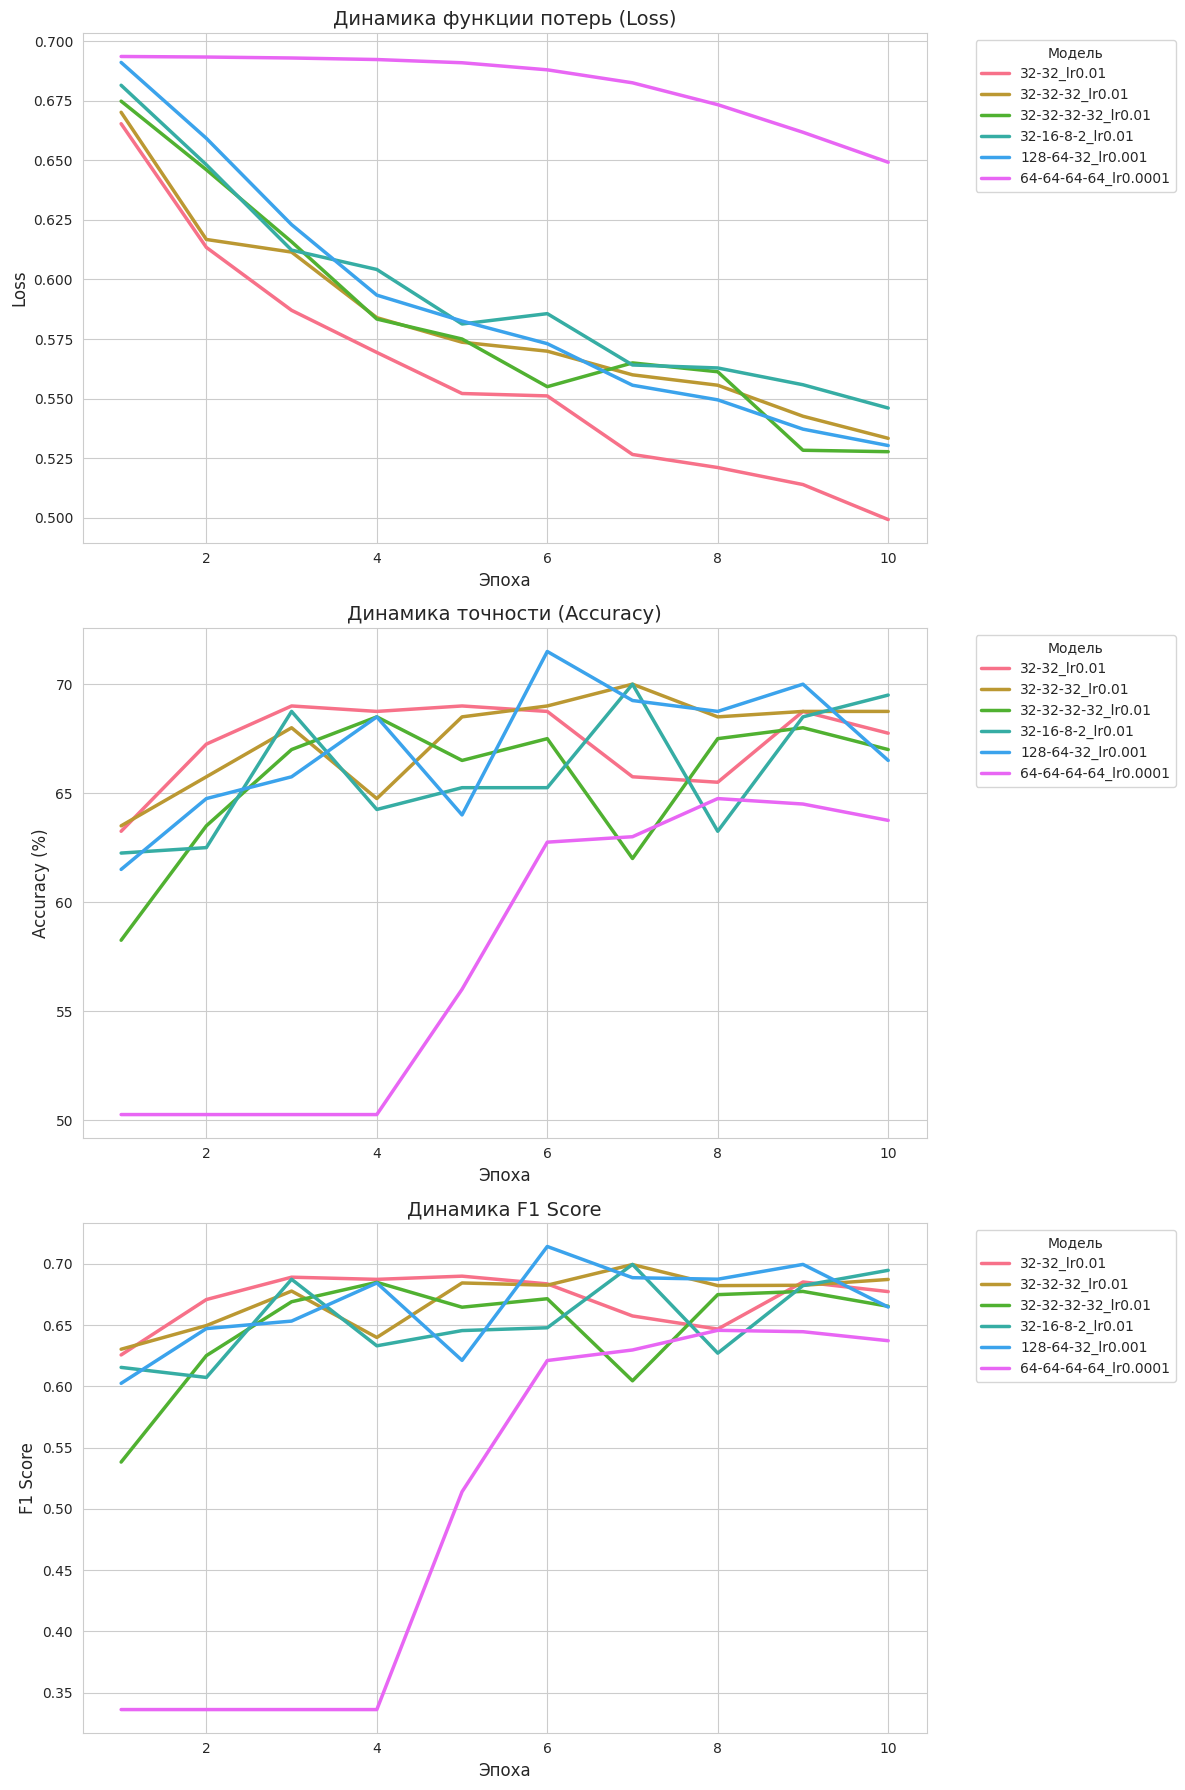

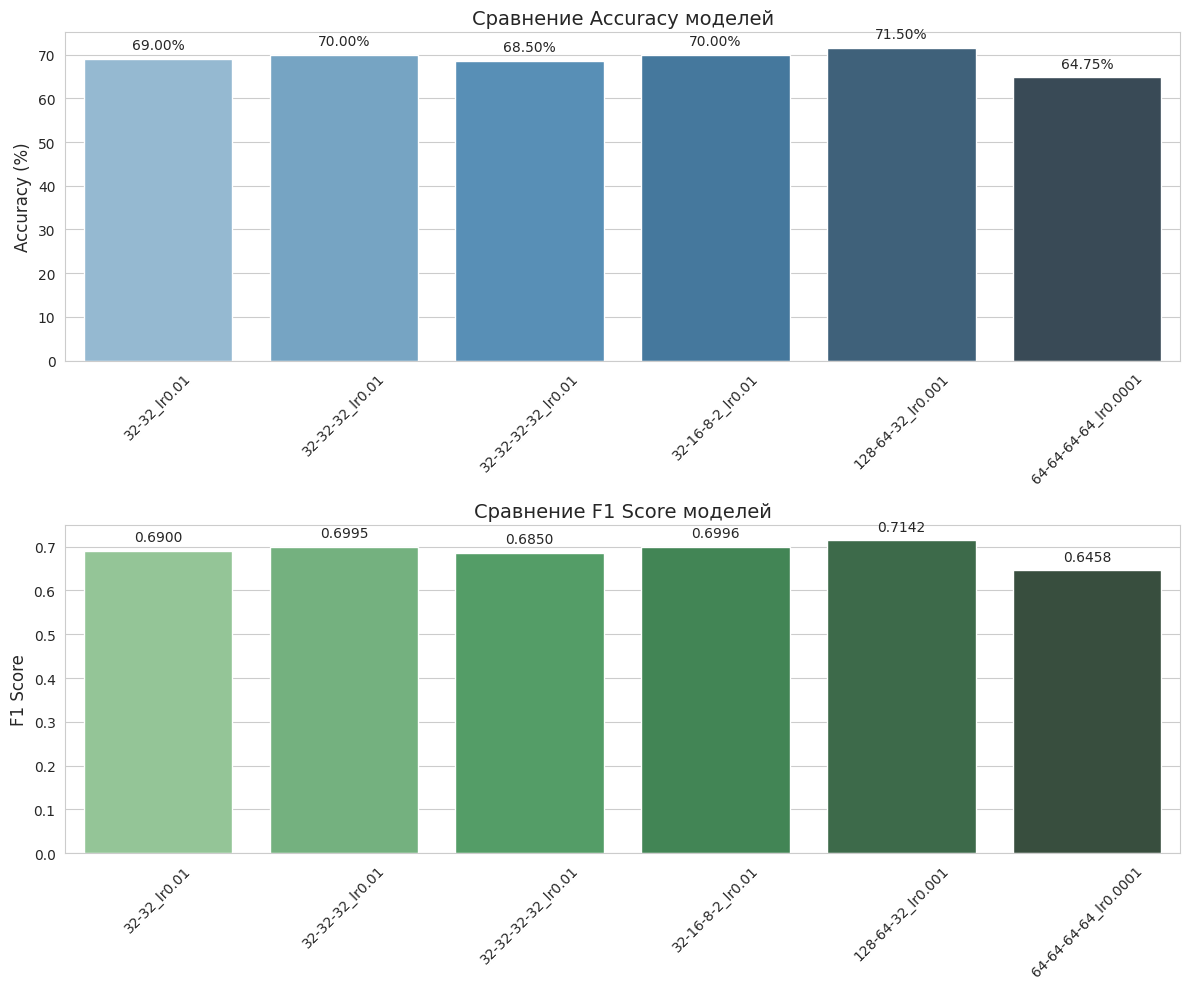

=== Сравнение моделей ===


,Model,Layers,Learning Rate,Best Accuracy,Best F1 Score,Final Loss
4,128-64-32_lr0.001,"[128, 64, 32]",0.0010,71.50,0.714214,0.530336
3,32-16-8-2_lr0.01,"[32, 16, 8, 2]",0.0100,70.00,0.699579,0.546066
1,32-32-32_lr0.01,"[32, 32, 32]",0.0100,70.00,0.699459,0.533362
0,32-32_lr0.01,"[32, 32]",0.0100,69.00,0.689984,0.499290
2,32-32-32-32_lr0.01,"[32, 32, 32, 32]",0.0100,68.50,0.684953,0.527756
5,64-64-64-64_lr0.0001,"[64, 64, 64, 64]",0.0001,64.75,0.645766,0.649152



=== Лучшая модель ===
Название: 128-64-32_lr0.001
Конфигурация слоев: [128, 64, 32]
Learning rate: 0.001
Accuracy: 71.50%
F1 Score: 0.7142
Final Loss: 0.5303


In [25]:
if __name__ == "__main__":
    experiments = [
        {'name': '32-32_lr0.01', 'layers': [32, 32], 'lr': 0.01, 'epochs': 10},
        {'name': '32-32-32_lr0.01', 'layers': [32, 32, 32], 'lr': 0.01, 'epochs': 10},
        {'name': '32-32-32-32_lr0.01', 'layers': [32, 32, 32, 32], 'lr': 0.01, 'epochs': 10},
        {'name': '32-16-8-2_lr0.01', 'layers': [32, 16, 8, 2], 'lr': 0.01, 'epochs': 10},
        {'name': '128-64-32_lr0.001', 'layers': [128, 64, 32], 'lr': 0.001, 'epochs': 10},
        {'name': '64-64-64-64_lr0.0001', 'layers': [64, 64, 64, 64], 'lr': 0.0001, 'epochs': 10}
    ]
    # experiments = [
    #     # 2 слоя (одинаковые нейроны)
    #     {'name': '32x32_lr0.01', 'layers': [32, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32x32_lr0.001', 'layers': [32, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32x32_lr0.0001', 'layers': [32, 32], 'lr': 0.0001, 'epochs': 10},

    #     {'name': '64x64_lr0.01', 'layers': [64, 64], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64x64_lr0.001', 'layers': [64, 64], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64x64_lr0.0001', 'layers': [64, 64], 'lr': 0.0001, 'epochs': 10},

    #     {'name': '128x128_lr0.01', 'layers': [128, 128], 'lr': 0.01, 'epochs': 10},
    #     {'name': '128x128_lr0.001', 'layers': [128, 128], 'lr': 0.001, 'epochs': 10},
    #     {'name': '128x128_lr0.0001', 'layers': [128, 128], 'lr': 0.0001, 'epochs': 10},

    #     # 2 слоя (разные нейроны)
    #     {'name': '32-16_lr0.01', 'layers': [32, 16], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32-16_lr0.001', 'layers': [32, 16], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32-16_lr0.0001', 'layers': [32, 16], 'lr': 0.0001, 'epochs': 10},

    #     {'name': '64-32_lr0.01', 'layers': [64, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64-32_lr0.001', 'layers': [64, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64-32_lr0.0001', 'layers': [64, 32], 'lr': 0.0001, 'epochs': 10},

    #     # 3 слоя (одинаковые нейроны)
    #     {'name': '32x32x32_lr0.01', 'layers': [32, 32, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32x32x32_lr0.001', 'layers': [32, 32, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32x32x32_lr0.0001', 'layers': [32, 32, 32], 'lr': 0.0001, 'epochs': 10},

    #     {'name': '64x64x64_lr0.01', 'layers': [64, 64, 64], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64x64x64_lr0.001', 'layers': [64, 64, 64], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64x64x64_lr0.0001', 'layers': [64, 64, 64], 'lr': 0.0001, 'epochs': 10},

    #     {'name': '128x128x128_lr0.01', 'layers': [128, 128, 128], 'lr': 0.01, 'epochs': 10},
    #     {'name': '128x128x128_lr0.001', 'layers': [128, 128, 128], 'lr': 0.001, 'epochs': 10},
    #     {'name': '128x128x128_lr0.0001', 'layers': [128, 128, 128], 'lr': 0.0001, 'epochs': 10},

    #     # 3 слоя (разные нейроны)
    #     {'name': '32-16-8_lr0.01', 'layers': [32, 16, 8], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32-16-8_lr0.001', 'layers': [32, 16, 8], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32-16-8_lr0.0001', 'layers': [32, 16, 8], 'lr': 0.0001, 'epochs': 10},

    #     {'name': '128-64-32_lr0.01', 'layers': [128, 64, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '128-64-32_lr0.001', 'layers': [128, 64, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '128-64-32_lr0.0001', 'layers': [128, 64, 32], 'lr': 0.0001, 'epochs': 10},

    #     # 4 слоя (одинаковые нейроны)
    #     {'name': '32x32x32x32_lr0.01', 'layers': [32, 32, 32, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32x32x32x32_lr0.001', 'layers': [32, 32, 32, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32x32x32x32_lr0.0001', 'layers': [32, 32, 32, 32], 'lr': 0.0001, 'epochs': 10},

    #     {'name': '64x64x64x64_lr0.01', 'layers': [64, 64, 64, 64], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64x64x64x64_lr0.001', 'layers': [64, 64, 64, 64], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64x64x64x64_lr0.0001', 'layers': [64, 64, 64, 64], 'lr': 0.0001, 'epochs': 10},

    #     {'name': '128x128x128x128_lr0.01', 'layers': [128, 128, 128, 128], 'lr': 0.01, 'epochs': 10},
    #     {'name': '128x128x128x128_lr0.001', 'layers': [128, 128, 128, 128], 'lr': 0.001, 'epochs': 10},
    #     {'name': '128x128x128x128_lr0.0001', 'layers': [128, 128, 128, 128], 'lr': 0.0001, 'epochs': 10},

    #     # 4 слоя (разные нейроны)
    #     {'name': '32-16-8-2_lr0.01', 'layers': [32, 16, 8, 2], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32-16-8-2_lr0.001', 'layers': [32, 16, 8, 2], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32-16-8-2_lr0.0001', 'layers': [32, 16, 8, 2], 'lr': 0.0001, 'epochs': 10},

    #     {'name': '64-32-16-8_lr0.01', 'layers': [64, 32, 16, 8], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64-32-16-8_lr0.001', 'layers': [64, 32, 16, 8], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64-32-16-8_lr0.0001', 'layers': [64, 32, 16, 8], 'lr': 0.0001, 'epochs': 10}
    # ]

    results_fasttext, metrics_df_fasttext = run_and_compare_experiments(X_token, y, experiments)

## Word to Vectores

In [31]:
import sys
import requests
from pymystem3 import Mystem

"""
Этот скрипт принимает на вход необработанный русский текст
(одно предложение на строку или один абзац на строку).
Он токенизируется, лемматизируется и размечается по частям речи с использованием Mystem.
На выход подаётся последовательность разделенных пробелами лемм с частями речи
("зеленый_NOUN трамвай_NOUN").
Их можно непосредственно использовать в моделях с RusVectōrēs (https://rusvectores.org).

Примеры запуска:
echo 'Мама мыла раму.' | python3 rus_preprocessing_mystem.py
zcat large_corpus.txt.gz | python3 rus_preprocessing_mystem.py | gzip > processed_corpus.txt.gz
"""


def tag_mystem(
    text="Текст нужно передать функции в виде строки!", mapping=None, postags=True
):
    # если частеречные тэги не нужны (например, их нет в модели), выставьте postags=False
    # в этом случае на выход будут поданы только леммы

    processed = m.analyze(text)
    tagged = []
    for w in processed:
        try:
            lemma = w["analysis"][0]["lex"].lower().strip()
            pos = w["analysis"][0]["gr"].split(",")[0]
            pos = pos.split("=")[0].strip()
            if mapping:
                if pos in mapping:
                    pos = mapping[pos]  # здесь мы конвертируем тэги
                else:
                    pos = "X"  # на случай, если попадется тэг, которого нет в маппинге
            tagged.append(lemma.lower() + "_" + pos)
        except KeyError:
            continue  # я здесь пропускаю знаки препинания, но вы можете поступить по-другому
    if not postags:
        tagged = [t.split("_")[0] for t in tagged]
    return tagged


# Таблица преобразования частеречных тэгов Mystem в тэги UPoS:
mapping_url = "https://raw.githubusercontent.com/akutuzov/universal-pos-tags/4653e8a9154e93fe2f417c7fdb7a357b7d6ce333/ru-rnc.map"

mystem2upos = {}
r = requests.get(mapping_url, stream=True)
for pair in r.text.split("\n"):
    pair = pair.split()
    if len(pair) > 1:
        mystem2upos[pair[0]] = pair[1]

print("Loading the model...", file=sys.stderr)
m = Mystem()

print("Processing input...", file=sys.stderr)
for line in sys.stdin:
    res = line.strip()
    output = tag_mystem(text=res, mapping=mystem2upos)
    print(" ".join(output))

Loading the model...
Processing input...


In [32]:
def extract_features(tokens):
    # Загрузка модели Word2Vec
    word2vec_model = KeyedVectors.load_word2vec_format("word2vec/model.bin", binary=True)

    # Инициализация Mystem (один раз при первом вызове)
    if not hasattr(extract_features, 'mystem_initialized'):
        from pymystem3 import Mystem
        import requests

        # Загрузка маппинга тегов
        mapping_url = "https://raw.githubusercontent.com/akutuzov/universal-pos-tags/4653e8a9154e93fe2f417c7fdb7a357b7d6ce333/ru-rnc.map"
        mystem2upos = {}
        r = requests.get(mapping_url)
        for pair in r.text.split("\n"):
            pair = pair.split()
            if len(pair) > 1:
                mystem2upos[pair[0]] = pair[1]

        extract_features.m = Mystem()
        extract_features.mystem2upos = mystem2upos
        extract_features.mystem_initialized = True

    features = []
    for token_list in tokens:
        # Преобразуем токены в формат RusVectōrēs
        text = ' '.join(token_list)
        processed_tokens = []
        for w in extract_features.m.analyze(text):
            try:
                lemma = w["analysis"][0]["lex"].lower().strip()
                pos = w["analysis"][0]["gr"].split(",")[0].split("=")[0].strip()
                pos = extract_features.mystem2upos.get(pos, "X")
                processed_tokens.append(f"{lemma}_{pos}")
            except (KeyError, IndexError):
                continue

        # Получаем вектора (используем сам word2vec_model вместо word2vec_model.wv)
        vectors = []
        for token in processed_tokens:
            try:
                vectors.append(word2vec_model[token])  # Изменено здесь
            except KeyError:
                continue

        # Усредняем вектора
        if vectors:
            avg_vector = np.mean(vectors, axis=0)
        else:
            avg_vector = np.zeros(word2vec_model.vector_size)

        features.append(avg_vector)

    return np.array(features)

Epoch [1/10], Loss: 0.6680, Test Accuracy: 58.25%, F1 Score: 0.5722
Epoch [2/10], Loss: 0.6194, Test Accuracy: 58.25%, F1 Score: 0.5801
Epoch [3/10], Loss: 0.5769, Test Accuracy: 60.00%, F1 Score: 0.5965
Epoch [4/10], Loss: 0.5547, Test Accuracy: 62.00%, F1 Score: 0.6180
Epoch [5/10], Loss: 0.5177, Test Accuracy: 59.50%, F1 Score: 0.5926
Epoch [6/10], Loss: 0.5015, Test Accuracy: 59.75%, F1 Score: 0.5971
Epoch [7/10], Loss: 0.5004, Test Accuracy: 59.50%, F1 Score: 0.5944
Epoch [8/10], Loss: 0.5038, Test Accuracy: 61.25%, F1 Score: 0.6117
Epoch [9/10], Loss: 0.4936, Test Accuracy: 57.75%, F1 Score: 0.5771
Epoch [10/10], Loss: 0.5027, Test Accuracy: 56.25%, F1 Score: 0.5621

=== Final Results ===
Model Name: 32-32_lr0.01
Layers Config: [32, 32]
Learning Rate: 0.01
Best Accuracy: 62.00%
Best F1 Score: 0.6180
=== Final Results ===

Epoch [1/10], Loss: 0.6710, Test Accuracy: 60.50%, F1 Score: 0.6047
Epoch [2/10], Loss: 0.6173, Test Accuracy: 55.75%, F1 Score: 0.5543
Epoch [3/10], Loss: 0.57

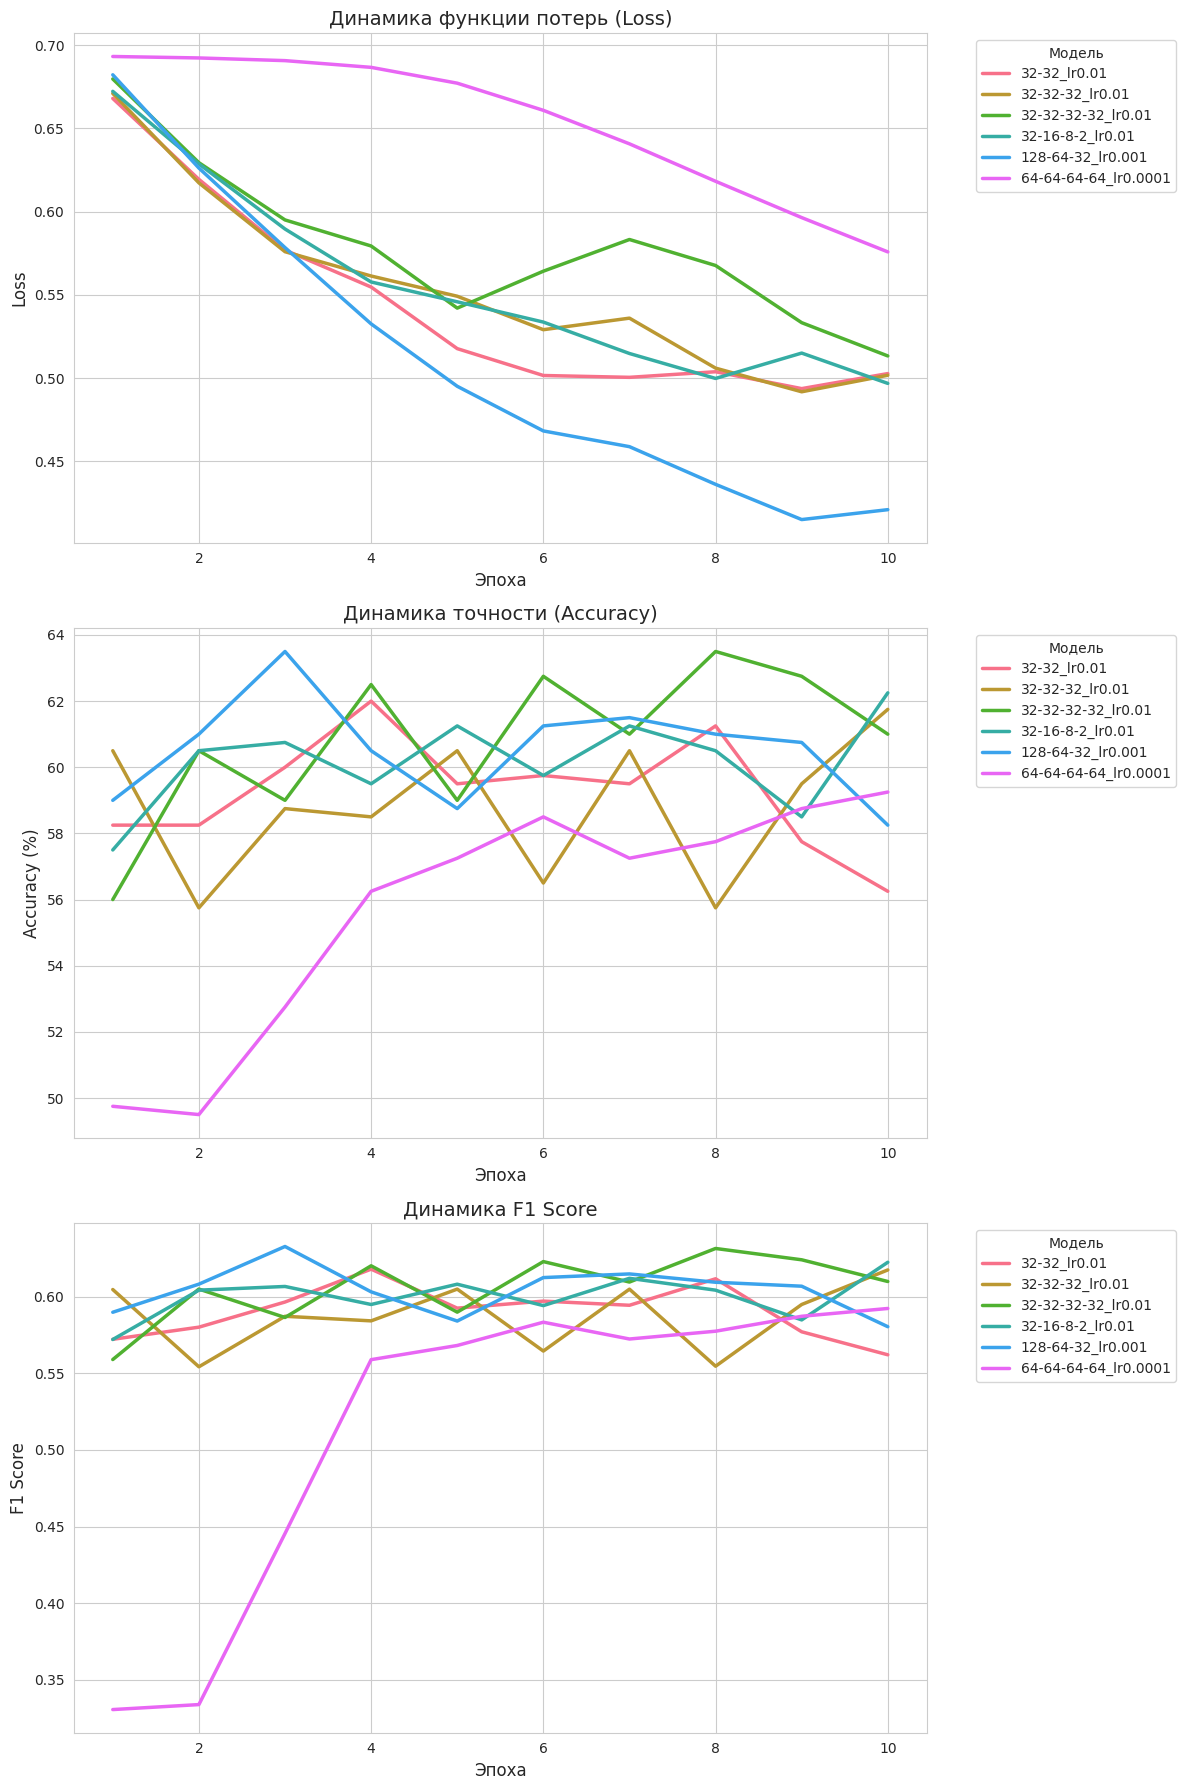

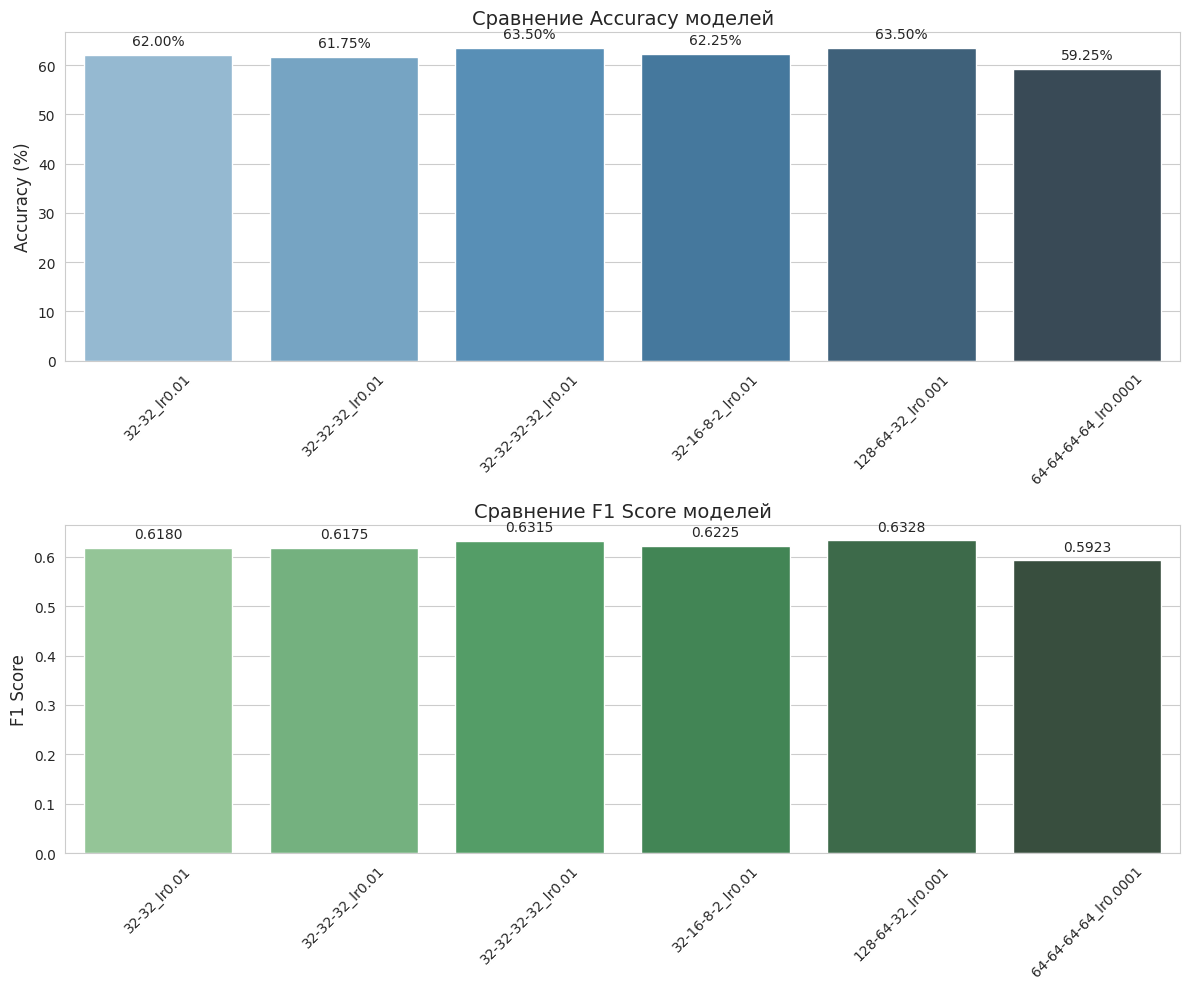

=== Сравнение моделей ===


,Model,Layers,Learning Rate,Best Accuracy,Best F1 Score,Final Loss
4,128-64-32_lr0.001,"[128, 64, 32]",0.0010,63.50,0.632796,0.420872
2,32-32-32-32_lr0.01,"[32, 32, 32, 32]",0.0100,63.50,0.631497,0.513254
3,32-16-8-2_lr0.01,"[32, 16, 8, 2]",0.0100,62.25,0.622502,0.496759
0,32-32_lr0.01,"[32, 32]",0.0100,62.00,0.617994,0.502654
1,32-32-32_lr0.01,"[32, 32, 32]",0.0100,61.75,0.617493,0.501647
5,64-64-64-64_lr0.0001,"[64, 64, 64, 64]",0.0001,59.25,0.592339,0.575789



=== Лучшая модель ===
Название: 128-64-32_lr0.001
Конфигурация слоев: [128, 64, 32]
Learning rate: 0.001
Accuracy: 63.50%
F1 Score: 0.6328
Final Loss: 0.4209


In [34]:
if __name__ == "__main__":
    experiments = [
        {'name': '32-32_lr0.01', 'layers': [32, 32], 'lr': 0.01, 'epochs': 10},
        {'name': '32-32-32_lr0.01', 'layers': [32, 32, 32], 'lr': 0.01, 'epochs': 10},
        {'name': '32-32-32-32_lr0.01', 'layers': [32, 32, 32, 32], 'lr': 0.01, 'epochs': 10},
        {'name': '32-16-8-2_lr0.01', 'layers': [32, 16, 8, 2], 'lr': 0.01, 'epochs': 10},
        {'name': '128-64-32_lr0.001', 'layers': [128, 64, 32], 'lr': 0.001, 'epochs': 10},
        {'name': '64-64-64-64_lr0.0001', 'layers': [64, 64, 64, 64], 'lr': 0.0001, 'epochs': 10}
    ]
    # experiments = [
    #     # 2 слоя (одинаковые нейроны)
    #     {'name': '32x32_lr0.01', 'layers': [32, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32x32_lr0.001', 'layers': [32, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32x32_lr0.0001', 'layers': [32, 32], 'lr': 0.0001, 'epochs': 10},

    #     {'name': '64x64_lr0.01', 'layers': [64, 64], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64x64_lr0.001', 'layers': [64, 64], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64x64_lr0.0001', 'layers': [64, 64], 'lr': 0.0001, 'epochs': 10},

    #     {'name': '128x128_lr0.01', 'layers': [128, 128], 'lr': 0.01, 'epochs': 10},
    #     {'name': '128x128_lr0.001', 'layers': [128, 128], 'lr': 0.001, 'epochs': 10},
    #     {'name': '128x128_lr0.0001', 'layers': [128, 128], 'lr': 0.0001, 'epochs': 10},

    #     # 2 слоя (разные нейроны)
    #     {'name': '32-16_lr0.01', 'layers': [32, 16], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32-16_lr0.001', 'layers': [32, 16], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32-16_lr0.0001', 'layers': [32, 16], 'lr': 0.0001, 'epochs': 10},

    #     {'name': '64-32_lr0.01', 'layers': [64, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64-32_lr0.001', 'layers': [64, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64-32_lr0.0001', 'layers': [64, 32], 'lr': 0.0001, 'epochs': 10},

    #     # 3 слоя (одинаковые нейроны)
    #     {'name': '32x32x32_lr0.01', 'layers': [32, 32, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32x32x32_lr0.001', 'layers': [32, 32, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32x32x32_lr0.0001', 'layers': [32, 32, 32], 'lr': 0.0001, 'epochs': 10},

    #     {'name': '64x64x64_lr0.01', 'layers': [64, 64, 64], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64x64x64_lr0.001', 'layers': [64, 64, 64], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64x64x64_lr0.0001', 'layers': [64, 64, 64], 'lr': 0.0001, 'epochs': 10},

    #     {'name': '128x128x128_lr0.01', 'layers': [128, 128, 128], 'lr': 0.01, 'epochs': 10},
    #     {'name': '128x128x128_lr0.001', 'layers': [128, 128, 128], 'lr': 0.001, 'epochs': 10},
    #     {'name': '128x128x128_lr0.0001', 'layers': [128, 128, 128], 'lr': 0.0001, 'epochs': 10},

    #     # 3 слоя (разные нейроны)
    #     {'name': '32-16-8_lr0.01', 'layers': [32, 16, 8], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32-16-8_lr0.001', 'layers': [32, 16, 8], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32-16-8_lr0.0001', 'layers': [32, 16, 8], 'lr': 0.0001, 'epochs': 10},

    #     {'name': '128-64-32_lr0.01', 'layers': [128, 64, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '128-64-32_lr0.001', 'layers': [128, 64, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '128-64-32_lr0.0001', 'layers': [128, 64, 32], 'lr': 0.0001, 'epochs': 10},

    #     # 4 слоя (одинаковые нейроны)
    #     {'name': '32x32x32x32_lr0.01', 'layers': [32, 32, 32, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32x32x32x32_lr0.001', 'layers': [32, 32, 32, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32x32x32x32_lr0.0001', 'layers': [32, 32, 32, 32], 'lr': 0.0001, 'epochs': 10},

    #     {'name': '64x64x64x64_lr0.01', 'layers': [64, 64, 64, 64], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64x64x64x64_lr0.001', 'layers': [64, 64, 64, 64], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64x64x64x64_lr0.0001', 'layers': [64, 64, 64, 64], 'lr': 0.0001, 'epochs': 10},

    #     {'name': '128x128x128x128_lr0.01', 'layers': [128, 128, 128, 128], 'lr': 0.01, 'epochs': 10},
    #     {'name': '128x128x128x128_lr0.001', 'layers': [128, 128, 128, 128], 'lr': 0.001, 'epochs': 10},
    #     {'name': '128x128x128x128_lr0.0001', 'layers': [128, 128, 128, 128], 'lr': 0.0001, 'epochs': 10},

    #     # 4 слоя (разные нейроны)
    #     {'name': '32-16-8-2_lr0.01', 'layers': [32, 16, 8, 2], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32-16-8-2_lr0.001', 'layers': [32, 16, 8, 2], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32-16-8-2_lr0.0001', 'layers': [32, 16, 8, 2], 'lr': 0.0001, 'epochs': 10},

    #     {'name': '64-32-16-8_lr0.01', 'layers': [64, 32, 16, 8], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64-32-16-8_lr0.001', 'layers': [64, 32, 16, 8], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64-32-16-8_lr0.0001', 'layers': [64, 32, 16, 8], 'lr': 0.0001, 'epochs': 10}
    # ]

    results_word2vec, metrics_df_word2vec = run_and_compare_experiments(X_token, y, experiments)

In [35]:
import numpy as np
import torch
import torch.nn as nn
from pymystem3 import Mystem
import requests

def extract_features(tokens):
    # Инициализация Mystem (один раз при первом вызове)
    if not hasattr(extract_features, 'mystem_initialized'):
        # Загрузка маппинга тегов
        mapping_url = "https://raw.githubusercontent.com/akutuzov/universal-pos-tags/4653e8a9154e93fe2f417c7fdb7a357b7d6ce333/ru-rnc.map"
        mystem2upos = {}
        r = requests.get(mapping_url)
        for pair in r.text.split("\n"):
            pair = pair.split()
            if len(pair) > 1:
                mystem2upos[pair[0]] = pair[1]

        extract_features.m = Mystem()
        extract_features.mystem2upos = mystem2upos
        extract_features.mystem_initialized = True

    # Создаем словарь для токенов
    if not hasattr(extract_features, 'vocab'):
        # Собираем все уникальные токены
        all_tokens = set()
        for token_list in tokens:
            text = ' '.join(token_list)
            for w in extract_features.m.analyze(text):
                try:
                    lemma = w["analysis"][0]["lex"].lower().strip()
                    pos = w["analysis"][0]["gr"].split(",")[0].split("=")[0].strip()
                    pos = extract_features.mystem2upos.get(pos, "X")
                    all_tokens.add(f"{lemma}_{pos}")
                except (KeyError, IndexError):
                    continue

        # Создаем словарь токенов
        extract_features.vocab = {token: idx for idx, token in enumerate(all_tokens)}
        extract_features.vocab_size = len(extract_features.vocab)

        # Инициализируем Embedding слой
        embedding_dim = 300  # Размерность эмбеддингов (можно изменить)
        extract_features.embedding = nn.Embedding(
            num_embeddings=extract_features.vocab_size,
            embedding_dim=embedding_dim
        )
        # Инициализируем веса (можно заменить на предобученные)
        nn.init.xavier_uniform_(extract_features.embedding.weight)

    features = []
    for token_list in tokens:
        # Преобразуем токены в формат RusVectōrēs
        text = ' '.join(token_list)
        processed_tokens = []
        for w in extract_features.m.analyze(text):
            try:
                lemma = w["analysis"][0]["lex"].lower().strip()
                pos = w["analysis"][0]["gr"].split(",")[0].split("=")[0].strip()
                pos = extract_features.mystem2upos.get(pos, "X")
                processed_tokens.append(f"{lemma}_{pos}")
            except (KeyError, IndexError):
                continue

        # Получаем индексы токенов
        token_indices = []
        for token in processed_tokens:
            if token in extract_features.vocab:
                token_indices.append(extract_features.vocab[token])

        # Если нет токенов, добавляем нулевой вектор
        if not token_indices:
            features.append(np.zeros(extract_features.embedding.embedding_dim))
            continue

        # Преобразуем в тензор
        token_indices = torch.LongTensor(token_indices)

        # Получаем эмбеддинги
        embeddings = extract_features.embedding(token_indices)

        # Усредняем эмбеддинги
        avg_embedding = torch.mean(embeddings, dim=0).detach().numpy()
        features.append(avg_embedding)

    return np.array(features)

Epoch [1/10], Loss: 0.6906, Test Accuracy: 51.50%, F1 Score: 0.3905
Epoch [2/10], Loss: 0.6759, Test Accuracy: 58.75%, F1 Score: 0.5712
Epoch [3/10], Loss: 0.6302, Test Accuracy: 57.75%, F1 Score: 0.5625
Epoch [4/10], Loss: 0.5995, Test Accuracy: 60.00%, F1 Score: 0.5982
Epoch [5/10], Loss: 0.5874, Test Accuracy: 60.00%, F1 Score: 0.5994
Epoch [6/10], Loss: 0.5688, Test Accuracy: 59.50%, F1 Score: 0.5937
Epoch [7/10], Loss: 0.5595, Test Accuracy: 59.50%, F1 Score: 0.5946
Epoch [8/10], Loss: 0.5500, Test Accuracy: 58.00%, F1 Score: 0.5791
Epoch [9/10], Loss: 0.5433, Test Accuracy: 59.00%, F1 Score: 0.5861
Epoch [10/10], Loss: 0.5311, Test Accuracy: 59.25%, F1 Score: 0.5899

=== Final Results ===
Model Name: 32-32_lr0.01
Layers Config: [32, 32]
Learning Rate: 0.01
Best Accuracy: 60.00%
Best F1 Score: 0.5994
=== Final Results ===

Epoch [1/10], Loss: 0.6933, Test Accuracy: 60.25%, F1 Score: 0.5989
Epoch [2/10], Loss: 0.6658, Test Accuracy: 60.75%, F1 Score: 0.6075
Epoch [3/10], Loss: 0.62

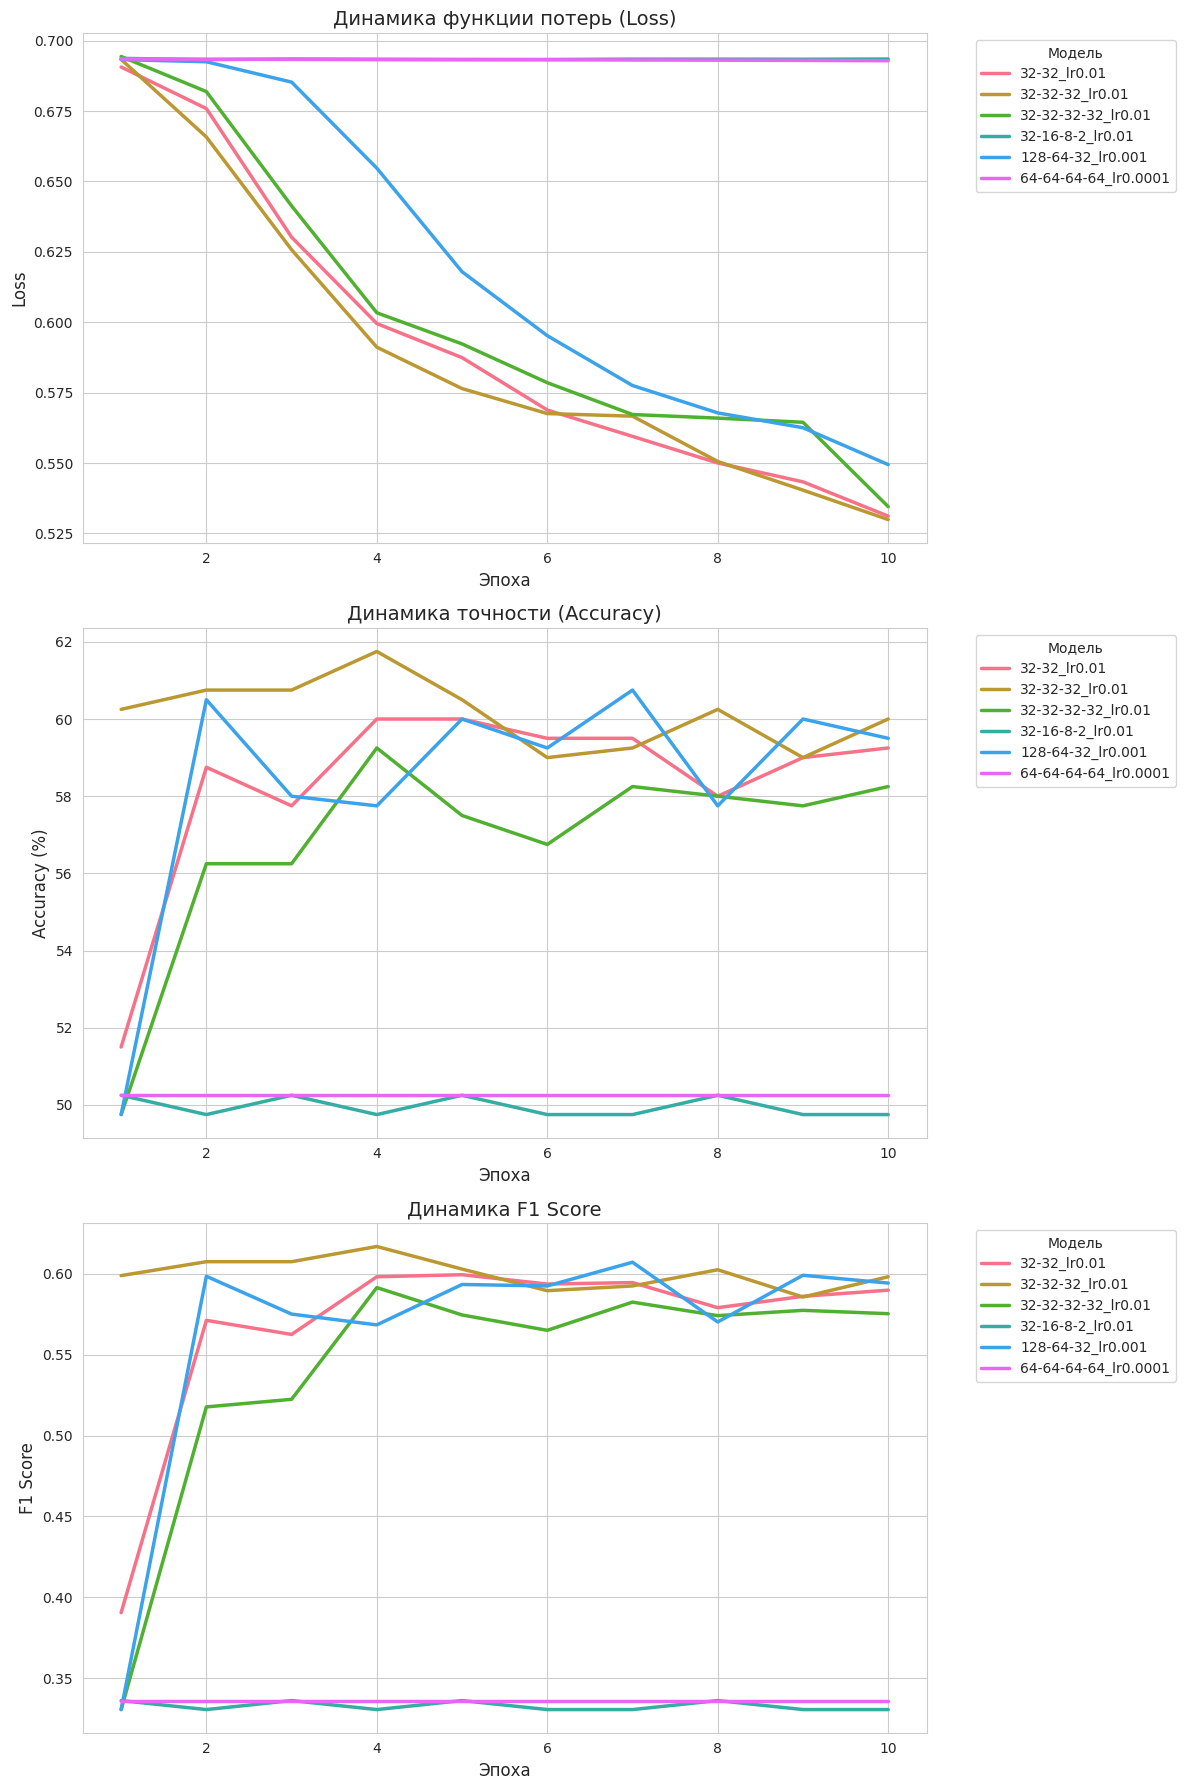

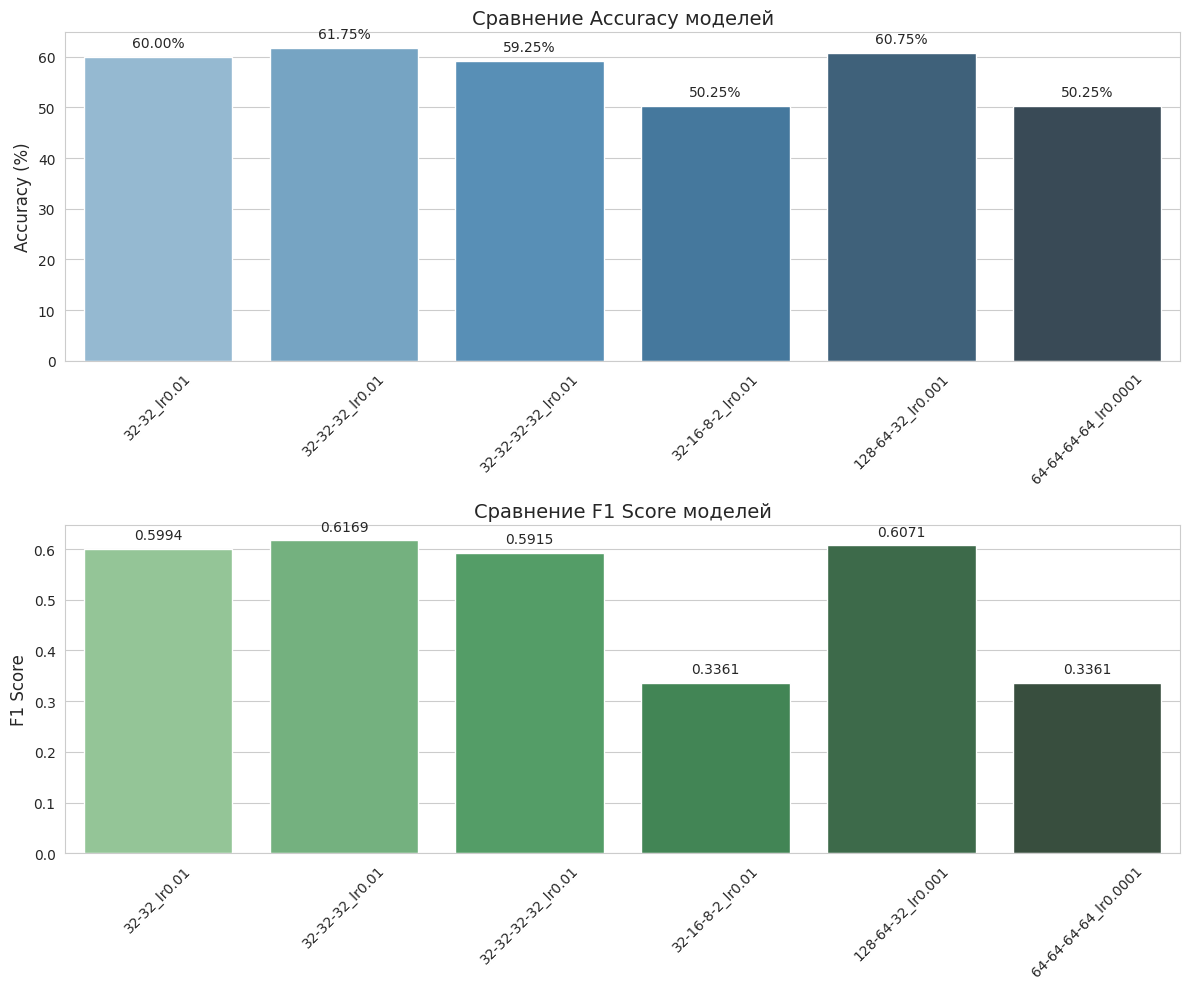

=== Сравнение моделей ===


,Model,Layers,Learning Rate,Best Accuracy,Best F1 Score,Final Loss
1,32-32-32_lr0.01,"[32, 32, 32]",0.0100,61.75,0.616889,0.529936
4,128-64-32_lr0.001,"[128, 64, 32]",0.0010,60.75,0.607149,0.549455
0,32-32_lr0.01,"[32, 32]",0.0100,60.00,0.599439,0.531149
2,32-32-32-32_lr0.01,"[32, 32, 32, 32]",0.0100,59.25,0.591481,0.534529
3,32-16-8-2_lr0.01,"[32, 16, 8, 2]",0.0100,50.25,0.336115,0.693463
5,64-64-64-64_lr0.0001,"[64, 64, 64, 64]",0.0001,50.25,0.336115,0.692857



=== Лучшая модель ===
Название: 32-32-32_lr0.01
Конфигурация слоев: [32, 32, 32]
Learning rate: 0.01
Accuracy: 61.75%
F1 Score: 0.6169
Final Loss: 0.5299


In [36]:
if __name__ == "__main__":
    experiments = [
        {'name': '32-32_lr0.01', 'layers': [32, 32], 'lr': 0.01, 'epochs': 10},
        {'name': '32-32-32_lr0.01', 'layers': [32, 32, 32], 'lr': 0.01, 'epochs': 10},
        {'name': '32-32-32-32_lr0.01', 'layers': [32, 32, 32, 32], 'lr': 0.01, 'epochs': 10},
        {'name': '32-16-8-2_lr0.01', 'layers': [32, 16, 8, 2], 'lr': 0.01, 'epochs': 10},
        {'name': '128-64-32_lr0.001', 'layers': [128, 64, 32], 'lr': 0.001, 'epochs': 10},
        {'name': '64-64-64-64_lr0.0001', 'layers': [64, 64, 64, 64], 'lr': 0.0001, 'epochs': 10}
    ]
    # experiments = [
    #     # 2 слоя (одинаковые нейроны)
    #     {'name': '32x32_lr0.01', 'layers': [32, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32x32_lr0.001', 'layers': [32, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32x32_lr0.0001', 'layers': [32, 32], 'lr': 0.0001, 'epochs': 10},

    #     {'name': '64x64_lr0.01', 'layers': [64, 64], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64x64_lr0.001', 'layers': [64, 64], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64x64_lr0.0001', 'layers': [64, 64], 'lr': 0.0001, 'epochs': 10},

    #     {'name': '128x128_lr0.01', 'layers': [128, 128], 'lr': 0.01, 'epochs': 10},
    #     {'name': '128x128_lr0.001', 'layers': [128, 128], 'lr': 0.001, 'epochs': 10},
    #     {'name': '128x128_lr0.0001', 'layers': [128, 128], 'lr': 0.0001, 'epochs': 10},

    #     # 2 слоя (разные нейроны)
    #     {'name': '32-16_lr0.01', 'layers': [32, 16], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32-16_lr0.001', 'layers': [32, 16], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32-16_lr0.0001', 'layers': [32, 16], 'lr': 0.0001, 'epochs': 10},

    #     {'name': '64-32_lr0.01', 'layers': [64, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64-32_lr0.001', 'layers': [64, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64-32_lr0.0001', 'layers': [64, 32], 'lr': 0.0001, 'epochs': 10},

    #     # 3 слоя (одинаковые нейроны)
    #     {'name': '32x32x32_lr0.01', 'layers': [32, 32, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32x32x32_lr0.001', 'layers': [32, 32, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32x32x32_lr0.0001', 'layers': [32, 32, 32], 'lr': 0.0001, 'epochs': 10},

    #     {'name': '64x64x64_lr0.01', 'layers': [64, 64, 64], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64x64x64_lr0.001', 'layers': [64, 64, 64], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64x64x64_lr0.0001', 'layers': [64, 64, 64], 'lr': 0.0001, 'epochs': 10},

    #     {'name': '128x128x128_lr0.01', 'layers': [128, 128, 128], 'lr': 0.01, 'epochs': 10},
    #     {'name': '128x128x128_lr0.001', 'layers': [128, 128, 128], 'lr': 0.001, 'epochs': 10},
    #     {'name': '128x128x128_lr0.0001', 'layers': [128, 128, 128], 'lr': 0.0001, 'epochs': 10},

    #     # 3 слоя (разные нейроны)
    #     {'name': '32-16-8_lr0.01', 'layers': [32, 16, 8], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32-16-8_lr0.001', 'layers': [32, 16, 8], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32-16-8_lr0.0001', 'layers': [32, 16, 8], 'lr': 0.0001, 'epochs': 10},

    #     {'name': '128-64-32_lr0.01', 'layers': [128, 64, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '128-64-32_lr0.001', 'layers': [128, 64, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '128-64-32_lr0.0001', 'layers': [128, 64, 32], 'lr': 0.0001, 'epochs': 10},

    #     # 4 слоя (одинаковые нейроны)
    #     {'name': '32x32x32x32_lr0.01', 'layers': [32, 32, 32, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32x32x32x32_lr0.001', 'layers': [32, 32, 32, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32x32x32x32_lr0.0001', 'layers': [32, 32, 32, 32], 'lr': 0.0001, 'epochs': 10},

    #     {'name': '64x64x64x64_lr0.01', 'layers': [64, 64, 64, 64], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64x64x64x64_lr0.001', 'layers': [64, 64, 64, 64], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64x64x64x64_lr0.0001', 'layers': [64, 64, 64, 64], 'lr': 0.0001, 'epochs': 10},

    #     {'name': '128x128x128x128_lr0.01', 'layers': [128, 128, 128, 128], 'lr': 0.01, 'epochs': 10},
    #     {'name': '128x128x128x128_lr0.001', 'layers': [128, 128, 128, 128], 'lr': 0.001, 'epochs': 10},
    #     {'name': '128x128x128x128_lr0.0001', 'layers': [128, 128, 128, 128], 'lr': 0.0001, 'epochs': 10},

    #     # 4 слоя (разные нейроны)
    #     {'name': '32-16-8-2_lr0.01', 'layers': [32, 16, 8, 2], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32-16-8-2_lr0.001', 'layers': [32, 16, 8, 2], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32-16-8-2_lr0.0001', 'layers': [32, 16, 8, 2], 'lr': 0.0001, 'epochs': 10},

    #     {'name': '64-32-16-8_lr0.01', 'layers': [64, 32, 16, 8], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64-32-16-8_lr0.001', 'layers': [64, 32, 16, 8], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64-32-16-8_lr0.0001', 'layers': [64, 32, 16, 8], 'lr': 0.0001, 'epochs': 10}
    # ]

    results_embedding, metrics_df_embedding = run_and_compare_experiments(X_token, y, experiments)

In [37]:
results = defaultdict(dict)
results['word2vec'] = results_word2vec
results['embedding'] = results_embedding
results['fasttext'] = results_fasttext

metrics = defaultdict(dict)
metrics['embedding'] = metrics_df_embedding
metrics['word2vec'] = metrics_df_word2vec
metrics['fasttext'] = metrics_df_fasttext

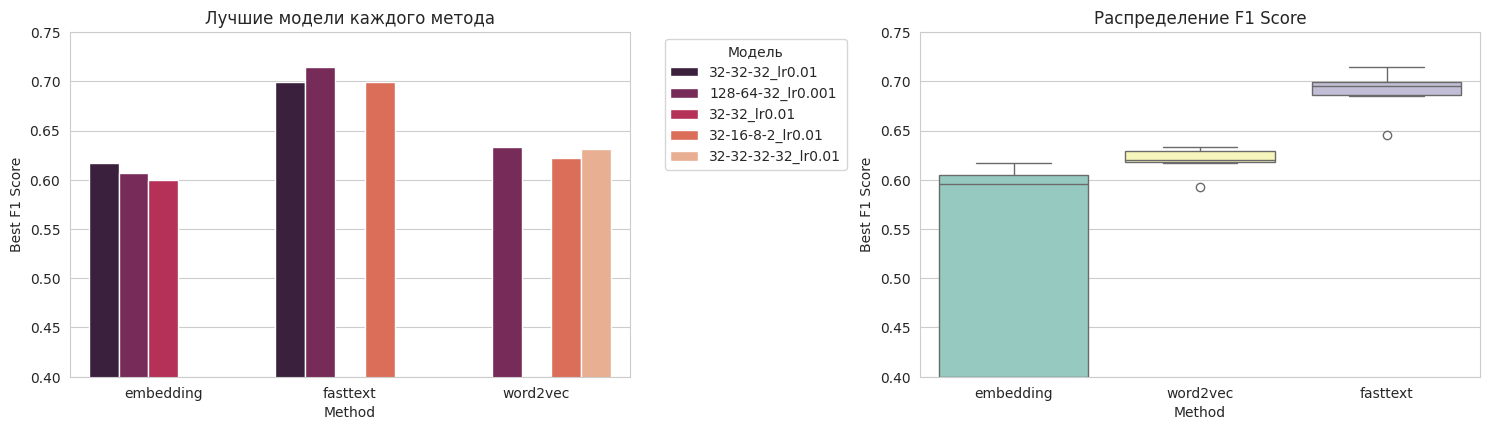

Топ-5 моделей по F1 Score:


,Rank,Method,Model,Best F1 Score,Best Accuracy,Final Loss
16,1,fasttext,128-64-32_lr0.001,0.714214,71.5,0.530336
15,2,fasttext,32-16-8-2_lr0.01,0.699579,70.0,0.546066
13,3,fasttext,32-32-32_lr0.01,0.699459,70.0,0.533362
12,4,fasttext,32-32_lr0.01,0.689984,69.0,0.499290
14,5,fasttext,32-32-32-32_lr0.01,0.684953,68.5,0.527756



Топ-3 модели каждого метода:


,Method,Model,Best F1 Score,Best Accuracy,Final Loss
1,embedding,32-32-32_lr0.01,0.616889,61.75,0.529936
4,embedding,128-64-32_lr0.001,0.607149,60.75,0.549455
0,embedding,32-32_lr0.01,0.599439,60.00,0.531149
16,fasttext,128-64-32_lr0.001,0.714214,71.50,0.530336
15,fasttext,32-16-8-2_lr0.01,0.699579,70.00,0.546066
13,fasttext,32-32-32_lr0.01,0.699459,70.00,0.533362
10,word2vec,128-64-32_lr0.001,0.632796,63.50,0.420872
8,word2vec,32-32-32-32_lr0.01,0.631497,63.50,0.513254
9,word2vec,32-16-8-2_lr0.01,0.622502,62.25,0.496759


In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Создаем объединенный DataFrame
full_df = pd.concat([
    metrics['embedding'].assign(Method='embedding'),
    metrics['word2vec'].assign(Method='word2vec'),
    metrics['fasttext'].assign(Method='fasttext')
]).reset_index(drop=True)

# 2. Получаем топ-модели
top_f1_global = full_df.nlargest(5, 'Best F1 Score').assign(Rank=range(1, 6))
top_f1_by_method = (full_df.sort_values(['Method', 'Best F1 Score'], ascending=[True, False])
                   .groupby('Method').head(3))

# 3. Визуализация с исправлениями
plt.figure(figsize=(15, 8))

# График 2: Топ-3 по методам
plt.subplot(2, 2, 1)
sns.barplot(data=top_f1_by_method, x='Method', y='Best F1 Score',
           hue='Model', palette='rocket', dodge=True)
plt.title('Лучшие модели каждого метода')
plt.ylim(0.4, 0.75)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Модель')

# График 3: Распределение F1 (исправленный)
plt.subplot(2, 2, 2)
sns.boxplot(data=full_df, x='Method', y='Best F1 Score',
           hue='Method', palette='Set3', legend=False)
plt.title('Распределение F1 Score')
plt.ylim(0.4, 0.75)


plt.tight_layout()
plt.show()

# 4. Вывод таблиц
print("Топ-5 моделей по F1 Score:")
display(top_f1_global[['Rank', 'Method', 'Model', 'Best F1 Score', 'Best Accuracy', 'Final Loss']]
       .sort_values('Rank'))

print("\nТоп-3 модели каждого метода:")
display(top_f1_by_method[['Method', 'Model', 'Best F1 Score', 'Best Accuracy', 'Final Loss']]
       .sort_values(['Method', 'Best F1 Score'], ascending=[True, False]))